# F1 Grand Prix Predictor
### Final Project Notebook Simple Draft

This notebook consolidates the current project into one readable workflow: **problem definition, dataset audit, exploratory analysis, cleaning, preprocessing, model comparison, and final interpretation**.

## 0. Setup and Configuration

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42
TARGET = "lap_duration"

# Keep None unless the team agrees on and documents an outlier-removal rule.
# Example: 0.99 would remove target values above the 99th percentile.
OUTLIER_UPPER_QUANTILE = 0.93

# Current simplest strategy: use session_type as a categorical model feature.
# Alternative experiments with separate Practice/Qualifying/Race models can be added later.
SESSION_STRATEGY = "feature"

# Model training can be expensive on the full dataset. Turn this on when ready.
RUN_MODELS = True

# Cross-validation can be expensive on the full dataset. Turn this on when ready.
RUN_CROSS_VALIDATION = False

# Feature engineering can be expensive on the full dataset. Turn this on when ready.
RUN_FEATURE_ENGINEERING = False

## 1. Problem and Dataset Overview

**Project type:** Supervised regression  
**Goal:** Predict the duration of an individual Formula 1 lap from known driver, team, circuit, tyre, grid, session, and weather information.  
**Target variable:** `lap_duration`, measured in seconds.  
**Unit of observation:** One row represents one recorded driver lap during one F1 session.

### Why the prediction is useful

- Estimates expected lap time under different combinations of driver, team, circuit, tyres, grid context, and weather.
- Enables more meaningful pace comparisons by accounting for changing race and environmental conditions.
- Highlights laps that differ from the model's expectation, supporting investigation of performance changes, tyre degradation, or unusual events.
- Allows controlled “what-if” comparisons when selected input conditions are changed.

### Current feature policy

**Used as model inputs when available**

- Driver/team: `driver_number`, `team_name`
- Weather: `air_temperature`, `track_temperature`, `humidity`, `rainfall`
- Circuit: `circuit_curvature`, `circuit_length`
- Tyres/stint: `stint_number`, `compound`, `tyre_age`
- Session/grid: `session_type`, `has_grid_position`, valid `position`

**Not used directly as model inputs**

- Join-only identifiers: `session_key`, `meeting_key`, `circuit_key`
- Alignment timestamp: `date_start`
- Redundant circuit label: `circuit_short_name`
- More specific session label: `session_name`
- `lap_number` under the current feature plan

`session_key` is still retained temporarily because it is useful for creating train/test splits without mixing laps from the same session.


### 1.1 Load the Master Dataset

In [73]:
try:
    df_raw = pd.read_json("https://meechai.me/Master.zip")
except:
    DATA_PATH_CANDIDATES = [
        Path("Master.json"),
        Path("/content/Master.json"),  # convenient when running in Google Colab
    ]

    data_path = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            "Master.json was not found. Run this notebook from the repository root "
            "or upload Master.json to the Colab session."
        )

    df_raw = pd.read_json(data_path)
    print(f"Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns from {data_path}.")
display(df_raw.head())


,session_key,driver_name,lap_number,date_start,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,circuit_key,circuit_short_name,session_name,session_type,circuit_curvature,circuit_length,team_name,position,has_grid_position,stint_number,compound,tyre_age
0,7765,Logan SARGEANT,1,2023-03-03T11:30:07.574Z,NaN,27.400,41.900,11.000,0.000,1141,63,Sakhir,Practice 1,Practice,27.505,"5,338.346",Williams,0,False,1.000,HARD,0.000
1,7765,Valtteri BOTTAS,1,2023-03-03T11:30:09.215Z,129.966,27.400,41.850,11.000,0.000,1141,63,Sakhir,Practice 1,Practice,27.505,"5,338.346",Alfa Romeo,0,False,1.000,MEDIUM,0.000
2,7765,ZHOU Guanyu,1,2023-03-03T11:30:14.011Z,140.357,27.400,41.850,11.000,0.000,1141,63,Sakhir,Practice 1,Practice,27.505,"5,338.346",Alfa Romeo,0,False,1.000,MEDIUM,0.000
3,7765,Lando NORRIS,1,2023-03-03T11:30:16.168Z,128.935,27.400,41.850,11.000,0.000,1141,63,Sakhir,Practice 1,Practice,27.505,"5,338.346",McLaren,0,False,1.000,MEDIUM,0.000
4,7765,Oscar PIASTRI,1,2023-03-03T11:30:26.277Z,142.794,27.367,41.833,11.000,0.000,1141,63,Sakhir,Practice 1,Practice,27.505,"5,338.346",McLaren,0,False,1.000,MEDIUM,0.000


### 1.2 Dataset Audit

In [74]:
expected_columns = [
    "session_key", "driver_name", "lap_number", "date_start", "lap_duration",
    "air_temperature", "track_temperature", "humidity", "rainfall",
    "meeting_key", "circuit_key", "circuit_short_name", "session_name",
    "session_type", "circuit_curvature", "circuit_length", "team_name",
    "position", "has_grid_position", "stint_number", "compound", "tyre_age",
]

column_audit = pd.DataFrame({
    "column": expected_columns,
    "present": [column in df_raw.columns for column in expected_columns],
    "dtype": [str(df_raw[column].dtype) if column in df_raw.columns else "missing" for column in expected_columns],
    "missing_values": [int(df_raw[column].isna().sum()) if column in df_raw.columns else np.nan for column in expected_columns],
})

display(column_audit)

unexpected_columns = sorted(set(df_raw.columns) - set(expected_columns))
if unexpected_columns:
    print("Additional columns found:", unexpected_columns)


,column,present,dtype,missing_values
0,session_key,True,int64,0
1,driver_name,True,str,0
2,lap_number,True,int64,0
3,date_start,True,str,0
4,lap_duration,True,float64,8493
5,air_temperature,True,float64,0
6,track_temperature,True,float64,0
7,humidity,True,float64,0
8,rainfall,True,float64,0
9,meeting_key,True,int64,0


In [75]:
summary_rows = {
    "Rows": len(df_raw),
    "Columns": df_raw.shape[1],
    "Missing target values": int(df_raw[TARGET].isna().sum()) if TARGET in df_raw else "TBD",
    "Unique sessions": int(df_raw["session_key"].nunique()) if "session_key" in df_raw else "TBD",
    "Unique circuits": int(df_raw["circuit_key"].nunique()) if "circuit_key" in df_raw else "TBD",
    "Unique drivers": int(df_raw["driver_number"].nunique()) if "driver_number" in df_raw else "TBD",
    "Unique teams": int(df_raw["team_name"].nunique()) if "team_name" in df_raw else "TBD",
}

if "date_start" in df_raw:
    dates = pd.to_datetime(df_raw["date_start"], errors="coerce", utc=True)
    summary_rows["First recorded date"] = dates.min()
    summary_rows["Last recorded date"] = dates.max()

summary_table = pd.DataFrame.from_dict(summary_rows, orient="index", columns=["Value"])
display(summary_table)


,Value
Rows,228212
Columns,22
Missing target values,8493
Unique sessions,404
Unique circuits,24
Unique drivers,TBD
Unique teams,15
First recorded date,2023-03-03 11:30:07.574000+00:00
Last recorded date,2026-07-26 14:42:56.288000+00:00


## 2. Exploratory Data Analysis and Visualizations

The EDA below focuses on questions that directly support cleaning and modeling:

1. How much data is missing?
2. What does the target distribution look like?
3. Do lap-time distributions differ by session type?
4. Does circuit length show the expected relationship with typical lap duration?
5. How do tyre compounds appear in the data?
6. How well do numerical variables correlate with each other and the target variable?

The plots are generated from the actual repository dataset. Any interpretation written in the final report should be updated after these cells are run.


### 2.1 Missing-Value Summary


,missing_count,missing_percent
compound,11880,5.206
stint_number,11783,5.163
tyre_age,11783,5.163
lap_duration,8493,3.722


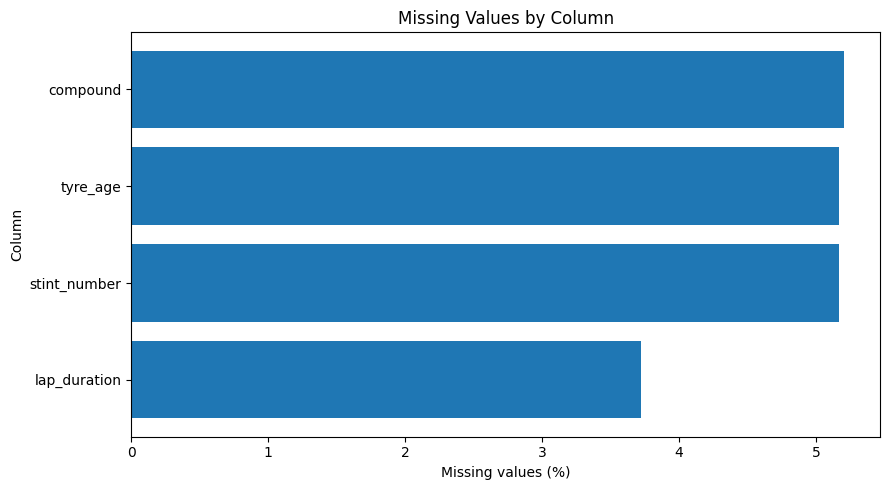

In [76]:
# not too happy with how this turned out, probably going to change the graph type tomorrow - Andres

missing_summary = (
    df_raw.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(df_raw))
    .sort_values("missing_count", ascending=False)
)

display(missing_summary[missing_summary["missing_count"] > 0])

plot_missing = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent")
if not plot_missing.empty:
    plt.figure(figsize=(9, 5))
    plt.barh(plot_missing.index, plot_missing["missing_percent"])
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values were found.")


In [77]:
# CODE DOWN BELOW IS PREVIOUSLY MADE, I DIDNT WANNA JUST DELETE IT - Andres


# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# df = pd.read_json("Master.json")


# display(df.head())
# display(df.info())
# display(df.describe())
# display(df.shape)

# categorical_features = ["driver_number", "circuit_key", "session_name", "team_name"]
# numerical_features = ["air_temperature", "track_temperature", "humidity", "rainfall", "position", "has_grid_position"]
# for feature in categorical_features:
#     print(f"{feature} count: {len(list(set(df[feature])))}")

# plt.hist(df["lap_duration"], bins=1000)
# plt.xscale("log")
# plt.xlabel("Lap duration (seconds)")
# plt.ylabel("Number of laps")
# plt.title("Distribution of F1 lap times")
# plt.show()

# # Observe this graph is wildly left-skewed. This will be addressed.

# # Needs correlation matrix

# # We will get more features such as tire type and age and maybe if the lap is a pit lap.

### 2.2 Target Distribution


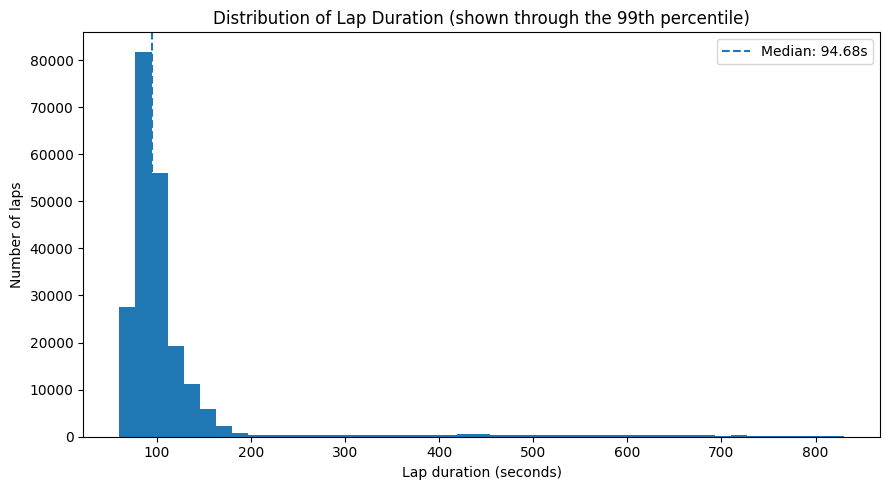

This plot is visually limited at the 99th percentile; it does not remove those rows from the dataset.


,lap_duration
count,"219,719.000"
mean,130.898
std,152.338
min,60.351
25%,82.779
50%,94.677
75%,111.354
max,"3,225.697"


In [78]:
if TARGET not in df_raw:
    raise KeyError(f"Required target column '{TARGET}' is missing.")

target_values = pd.to_numeric(df_raw[TARGET], errors="coerce").dropna()
plot_upper_limit = target_values.quantile(0.99)

plt.figure(figsize=(9, 5))
plt.hist(target_values[target_values <= plot_upper_limit], bins=45)
plt.axvline(target_values.median(), linestyle="--", label=f"Median: {target_values.median():.2f}s")
plt.xlabel("Lap duration (seconds)")
plt.ylabel("Number of laps")
plt.title("Distribution of Lap Duration (shown through the 99th percentile)")
plt.legend()
plt.tight_layout()
plt.show()

print("This plot is visually limited at the 99th percentile; it does not remove those rows from the dataset.")
display(target_values.describe().to_frame("lap_duration"))


### 2.3 Lap Duration by Session Type


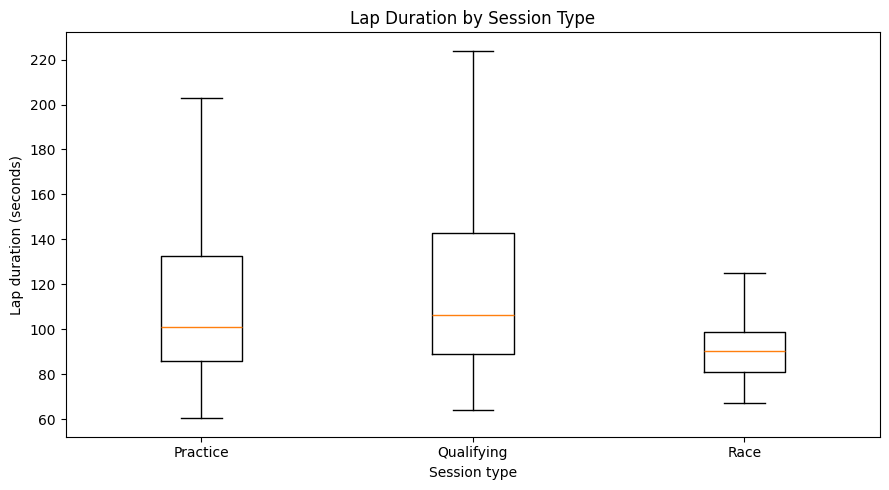

,count,mean,median,std
session_type,,,,
Race,106266,94.802,90.299,70.857
Practice,85459,157.307,101.010,187.403
Qualifying,27994,187.295,106.141,213.592


In [79]:
if "session_type" in df_raw.columns:
    session_plot = df_raw[["session_type", TARGET]].copy()
    session_plot[TARGET] = pd.to_numeric(session_plot[TARGET], errors="coerce")
    session_plot = session_plot.dropna()

    session_order = [
        value for value in ["Practice", "Qualifying", "Race"]
        if value in session_plot["session_type"].unique()
    ]
    session_order += [
        value for value in sorted(session_plot["session_type"].unique())
        if value not in session_order
    ]

    grouped_values = [
        session_plot.loc[session_plot["session_type"] == session, TARGET]
        for session in session_order
    ]

    plt.figure(figsize=(9, 5))
    plt.boxplot(grouped_values, tick_labels=session_order, showfliers=False)
    plt.xlabel("Session type")
    plt.ylabel("Lap duration (seconds)")
    plt.title("Lap Duration by Session Type")
    plt.tight_layout()
    plt.show()

    display(
        session_plot.groupby("session_type")[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median")
    )
else:
    print("session_type is unavailable, so this plot is skipped.")


### 2.4 Circuit Length and Typical Lap Duration


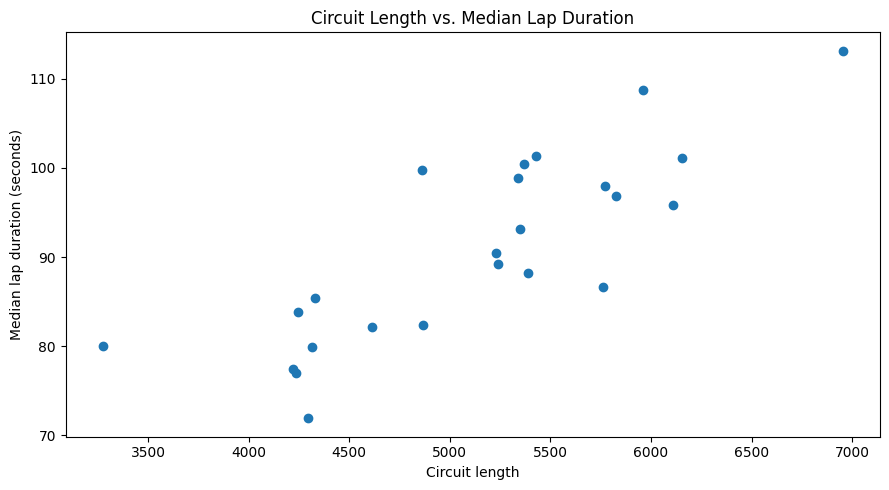

,circuit_short_name,circuit_length,median_lap_duration,lap_count
0,Monte Carlo,"3,274.692",79.987,16994
1,Zandvoort,"4,221.066",77.430,8528
2,Interlagos,"4,235.159",76.977,8069
3,Mexico City,"4,243.679",83.817,8858
4,Spielberg,"4,296.363",71.905,12114
5,Montreal,"4,312.662",79.941,11772
6,Hungaroring,"4,327.362",85.410,11600
7,Catalunya,"4,612.772",82.112,11506
8,Singapore,"4,863.487",99.736,7985
9,Imola,"4,868.328",82.392,5401


In [80]:
required = {"circuit_short_name", "circuit_length", TARGET}
if required.issubset(df_raw.columns):
    circuit_summary = (
        df_raw[list(required)]
        .assign(
            circuit_length=lambda x: pd.to_numeric(x["circuit_length"], errors="coerce"),
            lap_duration=lambda x: pd.to_numeric(x[TARGET], errors="coerce"),
        )
        .dropna()
        .groupby("circuit_short_name", as_index=False)
        .agg(
            circuit_length=("circuit_length", "median"),
            median_lap_duration=(TARGET, "median"),
            lap_count=(TARGET, "size"),
        )
    )

    plt.figure(figsize=(9, 5))
    plt.scatter(circuit_summary["circuit_length"], circuit_summary["median_lap_duration"])
    plt.xlabel("Circuit length")
    plt.ylabel("Median lap duration (seconds)")
    plt.title("Circuit Length vs. Median Lap Duration")
    plt.tight_layout()
    plt.show()

    display(circuit_summary.sort_values("circuit_length").reset_index(drop=True))
else:
    print("Circuit-length analysis skipped because one or more required columns are missing.")


### 2.5 Tyre Compound Snapshot


In [81]:
if "compound" in df_raw.columns:
    compound_summary = (
        df_raw[["compound", TARGET]]
        .assign(lap_duration=lambda x: pd.to_numeric(x[TARGET], errors="coerce"))
        .dropna()
        .groupby("compound")[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("count", ascending=False)
    )
    display(compound_summary)
else:
    print("compound is unavailable, so this summary is skipped.")


,count,mean,median,std
compound,,,,
MEDIUM,71964,114.353,93.148,109.698
SOFT,65477,168.934,99.582,202.406
HARD,60919,100.923,91.336,75.394
INTERMEDIATE,8313,146.277,98.725,230.634
TEST_UNKNOWN,1206,138.986,84.781,217.602
WET,784,208.245,113.258,354.806
UNKNOWN,80,365.330,112.694,595.820


### 2.6 Correlation Matrix

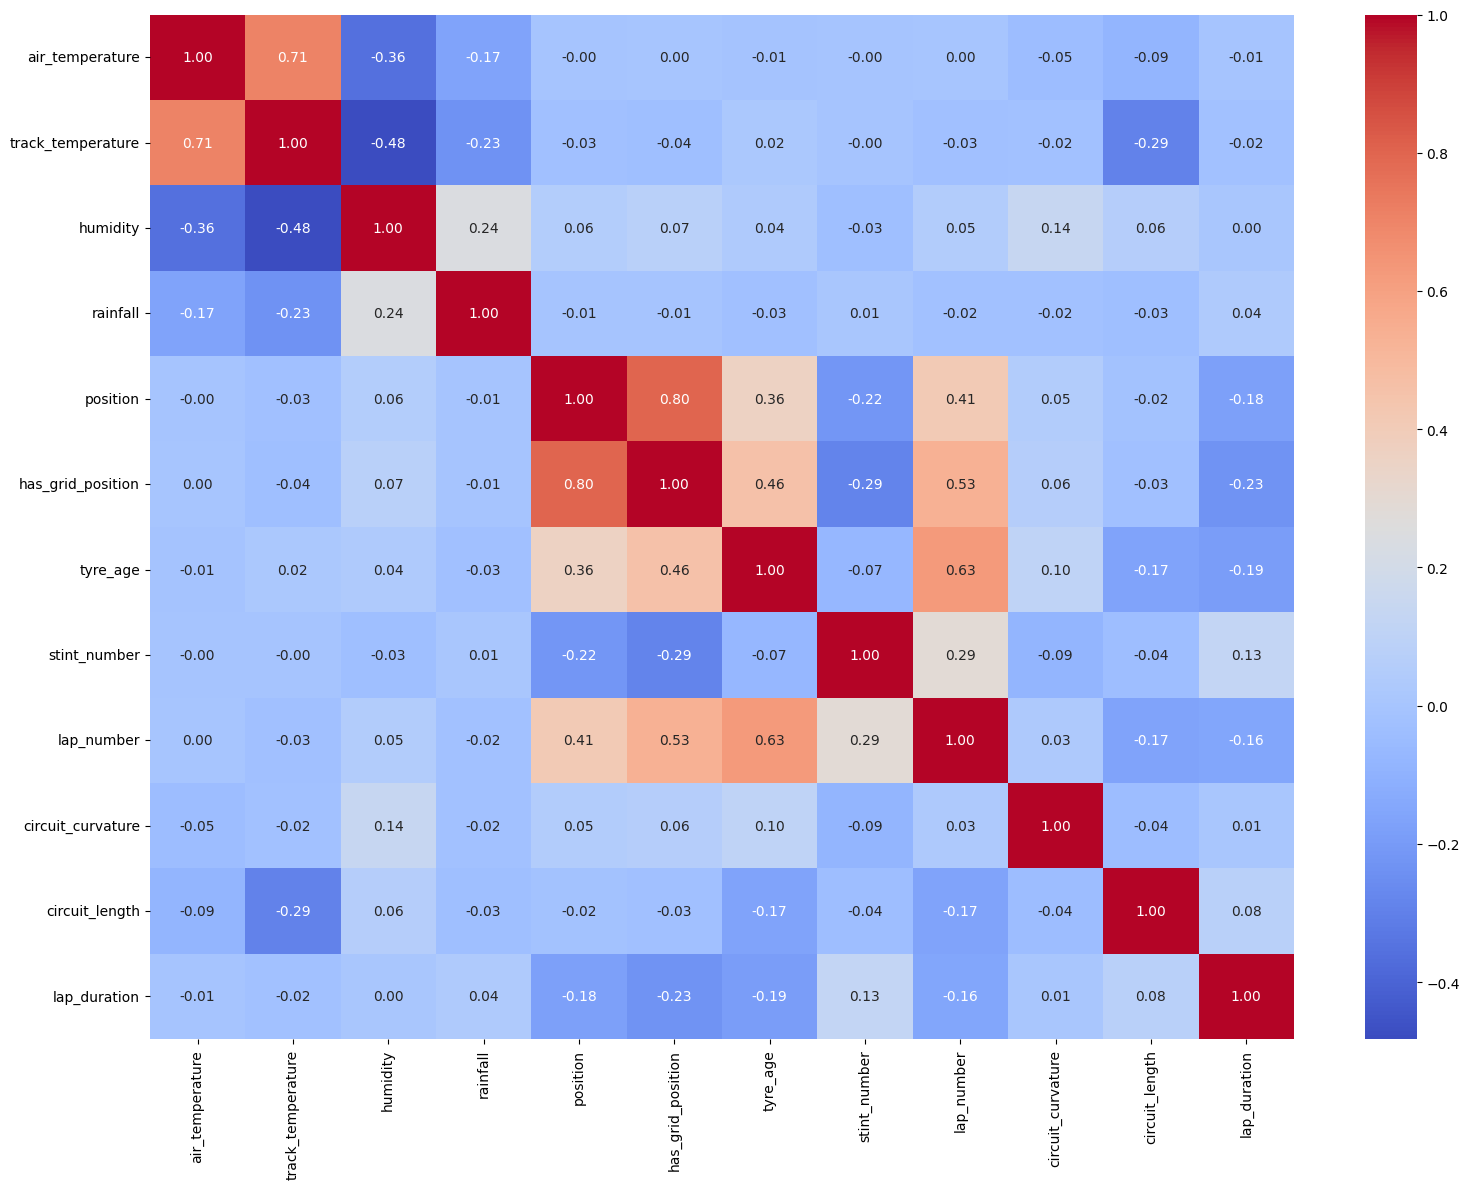

In [82]:
numerical_features = ["air_temperature", "track_temperature", "humidity",
                      "rainfall", "position", "has_grid_position",
                      "tyre_age", "stint_number", "lap_number",
                      "circuit_curvature", "circuit_length"
                      ]

plt.figure(figsize=(16, 12))
ax = sns.heatmap(df_raw[numerical_features + ["lap_duration"]].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.tight_layout()
plt.show()

### 2.7 EDA Interpretation (Update After Running)

Replace the statements below with observations supported by the generated figures.

- **Target distribution:** TBD
- **Session-type differences:** TBD
- **Circuit-length relationship:** TBD
- **Tyre-compound pattern:** TBD
- **Missing-data concern that most affects modeling:** TBD

Avoid treating correlation as causation. For example, compound differences can also reflect circuit, session, fuel, weather, traffic, and driver effects.


## 3. Data Cleaning and Feature Preparation

This notebook uses a conservative cleaning policy:

1. Remove exact duplicate rows.
2. Convert the target and numeric fields to numeric values.
3. Remove rows with missing, non-finite, or non-positive `lap_duration`.
4. Use grid position only when `has_grid_position` is true.
5. Leave feature-level missing values for the preprocessing pipeline to impute.
6. Do **not** remove a fixed percentage of the slowest laps unless the team agrees on and documents that rule.

The older model notebooks use different target cutoffs (90th and 93rd percentiles). A final comparison should use one shared cleaning rule.


In [83]:
def coerce_boolean(series: pd.Series) -> pd.Series:
    """Convert common boolean representations while preserving missing values."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")

    mapping = {
        True: True, False: False,
        1: True, 0: False,
        "1": True, "0": False,
        "true": True, "false": False,
        "True": True, "False": False,
    }
    return series.map(mapping).astype("boolean")


def clean_lap_data(raw_df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    df = raw_df.copy()
    audit = {"starting_rows": len(df)}

    duplicate_count = int(df.duplicated().sum())
    df = df.drop_duplicates().copy()
    audit["exact_duplicates_removed"] = duplicate_count

    if "date_start" in df.columns:
        df["date_start"] = pd.to_datetime(df["date_start"], errors="coerce", utc=True)
        df["year"] = df["date_start"].dt.year

    numeric_candidates = [
        TARGET, "lap_number", "air_temperature", "track_temperature", "humidity",
        "rainfall", "circuit_curvature", "circuit_length", "position",
        "stint_number", "tyre_age",
    ]
    for column in numeric_candidates:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

    if TARGET not in df.columns:
        raise KeyError(f"Required target column '{TARGET}' is missing.")

    invalid_target = df[TARGET].isna() | ~np.isfinite(df[TARGET]) | (df[TARGET] <= 0)
    audit["invalid_target_rows_removed"] = int(invalid_target.sum())
    df = df.loc[~invalid_target].copy()

    if "has_grid_position" in df.columns:
        df["has_grid_position"] = coerce_boolean(df["has_grid_position"])

    if {"position", "has_grid_position"}.issubset(df.columns):
        valid_grid = df["has_grid_position"].fillna(False)
        df["grid_position_when_valid"] = np.where(valid_grid, df["position"], 0)

    if OUTLIER_UPPER_QUANTILE is not None:
        cutoff = df[TARGET].quantile(OUTLIER_UPPER_QUANTILE)
        outlier_mask = df[TARGET] > cutoff
        audit["upper_target_rows_removed"] = int(outlier_mask.sum())
        audit["upper_target_cutoff_seconds"] = float(cutoff)
        df = df.loc[~outlier_mask].copy()
    else:
        audit["upper_target_rows_removed"] = 0
        audit["upper_target_cutoff_seconds"] = "Not applied"

    audit["final_rows"] = len(df)
    return df.reset_index(drop=True), audit


df_clean, cleaning_audit = clean_lap_data(df_raw)
display(pd.DataFrame.from_dict(cleaning_audit, orient="index", columns=["Value"]))
print(f"Cleaned dataset shape: {df_clean.shape}")


,Value
starting_rows,228212
exact_duplicates_removed,2422
invalid_target_rows_removed,8474
upper_target_rows_removed,0
upper_target_cutoff_seconds,Not applied
final_rows,217316


Cleaned dataset shape: (217316, 24)


The below is the code used to generate the Circuit graphs, circuit curvature, and circuit length features:

The results of this code are already in the Master.json, so there is no need to run. But running it will create a new .json file with just the track curvatures and lengths, as well as several 3d plots that show the layout of each track. It will add more time to the Notebook runtime. 

If you wish to run the feature engineering pipeline, set the variable **RUN_FEATURE_ENGINEERING** to true in the first Code Cell

In [ ]:
import json
import os
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import CubicSpline

from GetData import SESSIONS_DIR, YEAR_FILE_PATTERN, openf1_get

PLOTS_DIR = "Plots"

if RUN_FEATURE_ENGINEERING:
    # Download sessions data before running the curvature pipeline
    os.makedirs(SESSIONS_DIR, exist_ok=True)
    years = range(2023, 2027)
    now = datetime.now(timezone.utc).isoformat()

    for year in years:
        sessions = openf1_get("sessions", params={"year": year, "date_start<": now})
        sessions = [
            session
            for session in sessions
            if not (
                session["session_type"] == "Practice"
                and session["session_name"].startswith("Day ")
            )
            and not session["is_cancelled"]
        ]
        sessions = [
            {
                "session_key": session["session_key"],
                "meeting_key": session["meeting_key"],
                "circuit_key": session["circuit_key"],
                "circuit_short_name": session["circuit_short_name"],
                "session_name": session["session_name"],
                "session_type": session["session_type"],
            }
            for session in sessions
        ]

        out_path = os.path.join(SESSIONS_DIR, f"{year}.json")
        with open(out_path, "w") as f:
            json.dump(sessions, f, indent=2)

    # OpenF1's /location x, y, z are in tenths of a meter, not meters -
    # confirmed by comparing summed chord length against known official lap
    # distances (e.g. Monaco's ~3337 m, Montreal's ~4361 m both come out to
    # within ~2% once divided by 10).
    METERS_PER_UNIT = 0.1


    def fit_splines(df: pd.DataFrame, bc_type: str = "not-a-knot", closed: bool = False):
        """
        Fit piecewise cubic splines to the x, y, z columns of df, parametrized
        by cumulative chord-length distance between consecutive points.

        scipy's CubicSpline enforces C2 continuity by construction, so each
        segment already matches first and second derivatives with its
        neighbors at every point where they connect.

        If closed is True, a copy of the first point is appended after the
        last one, adding a segment that closes the loop back to the start,
        and bc_type is forced to "periodic" so that closing segment also
        matches first and second derivatives with its neighbors instead of
        just being a plain line back to the start.

        Returns (t, splines) where t is the parameter array and splines is a
        dict of CubicSpline objects keyed by 'x', 'y', 'z'.
        """
        if closed:
            df = pd.concat([df, df.iloc[[0]]], ignore_index=True)
            bc_type = "periodic"

        x = df["x"].to_numpy(dtype=float)
        y = df["y"].to_numpy(dtype=float)
        z = df["z"].to_numpy(dtype=float)

        deltas = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2 + np.diff(z) ** 2)
        t = np.concatenate(([0.0], np.cumsum(deltas)))

        # Consecutive samples with identical (x, y, z) produce a zero-length
        # step, which leaves t merely non-decreasing instead of the strictly
        # increasing sequence CubicSpline requires - drop those duplicates.
        keep = np.concatenate(([True], deltas > 0))
        t, x, y, z = t[keep], x[keep], y[keep], z[keep]

        splines = {
            "x": CubicSpline(t, x, bc_type=bc_type),
            "y": CubicSpline(t, y, bc_type=bc_type),
            "z": CubicSpline(t, z, bc_type=bc_type),
        }
        return t, splines


    def compute_curvature(splines: dict, t: np.ndarray) -> np.ndarray:
        """
        Curvature of the 3D parametric spline curve r(t) = (x(t), y(t), z(t)):
            kappa(t) = |r'(t) x r''(t)| / |r'(t)|^3
        """
        dx, dy, dz = (splines[c].derivative(1) for c in ("x", "y", "z"))
        ddx, ddy, ddz = (splines[c].derivative(2) for c in ("x", "y", "z"))

        r1 = np.stack([dx(t), dy(t), dz(t)], axis=-1)
        r2 = np.stack([ddx(t), ddy(t), ddz(t)], axis=-1)

        numerator = np.linalg.norm(np.cross(r1, r2), axis=-1)
        denominator = np.linalg.norm(r1, axis=-1) ** 3

        kappa = np.zeros_like(numerator)
        nonzero = denominator > 0
        kappa[nonzero] = numerator[nonzero] / denominator[nonzero]
        return kappa


    def get_track_curvatures():
        """
        Read every Sessions/{year}.json file produced by get_sessions() and,
        for each meeting's Qualifying session on a circuit not already seen,
        pull driver #1's xyz location data for their last full lap from
        OpenF1's /location endpoint, then immediately fit splines and reduce
        it to a total curvature value - one circuit at a time, rather than
        collecting every circuit's raw location data before processing any
        of it.

        A lap's date_start marks when it begins, so a full lap is the
        interval between one lap's date_start (its start) and the next lap's
        date_start (its end). The last lap of a race is especially likely to
        be contaminated by things that aren't a clean racing lap - a red
        flag or safety car parking the field for minutes, or the winner
        doing a slow-down/celebration lap before crossing back through the
        timing loop - so instead of blindly trusting the final pair, this
        walks backward from the end of the race looking for the most recent
        lap whose actual elapsed time (next lap's date_start minus this
        lap's date_start) is within 1.5x the session's median lap_duration,
        and uses that as the "last full lap" instead.

        Also plots each circuit's raw points and fitted splines together on
        an interactive 3D figure and saves it to Plots/{circuit_short_name}.html -
        open it in a browser to rotate/zoom/pan.

        Returns a dict mapping circuit_key -> {"total_curvature": ...,
        "length_m": ...}, one entry per distinct circuit. total_curvature is
        the integral of curvature over arc length (total turning angle, in
        radians) and is scale-invariant, so it captures how twisty a track
        is independent of its size - length_m (the lap's arc length,
        converted from OpenF1's native units via METERS_PER_UNIT) is stored
        alongside it so track size isn't lost.
        """
        os.makedirs(PLOTS_DIR, exist_ok=True)
        circuit_map = {}

        for filename in os.listdir(SESSIONS_DIR):
            if not YEAR_FILE_PATTERN.match(filename):
                continue

            with open(os.path.join(SESSIONS_DIR, filename)) as f:
                sessions = json.load(f)

            for session in sessions:
                if session["session_name"] != "Race":
                    continue

                circuit_key = session["circuit_key"]
                circuit_name = session["circuit_short_name"]
                if circuit_key in circuit_map:
                    continue

                session_key = session["session_key"]
                laps = openf1_get(
                    "laps", params={"session_key": session_key, "driver_number": 1}
                )
                laps = sorted(laps, key=lambda lap: lap["lap_number"])

                if len(laps) < 2:
                    continue

                durations = [lap["lap_duration"] for lap in laps if lap["lap_duration"]]
                if not durations:
                    continue
                median_duration = np.median(durations)

                second_last_lap_start = last_lap_start = None
                for i in range(len(laps) - 2, -1, -1):
                    start, end = laps[i]["date_start"], laps[i + 1]["date_start"]
                    if not (start and end):
                        continue
                    gap = (pd.Timestamp(end) - pd.Timestamp(start)).total_seconds()
                    if gap <= 1.5 * median_duration:
                        second_last_lap_start, last_lap_start = start, end
                        break

                if last_lap_start is None:
                    continue

                location = openf1_get(
                    "location",
                    params={
                        "session_key": session_key,
                        "driver_number": 1,
                        "date>": second_last_lap_start,
                        "date<": last_lap_start,
                    },
                )
                if len(location) < 4:
                    continue

                df = pd.DataFrame(location)[["x", "y", "z"]]

                t, splines = fit_splines(df, closed=True)
                kappa = compute_curvature(splines, t)
                circuit_map[circuit_key] = {
                    "total_curvature": np.trapezoid(kappa, t),
                    "length_m": t[-1] * METERS_PER_UNIT,
                }

                t_fine = np.linspace(t[0], t[-1], 500)
                spline_x, spline_y, spline_z = (splines[c](t_fine) for c in "xyz")

                fig = go.Figure(
                    data=[
                        go.Scatter3d(
                            x=df["x"],
                            y=df["y"],
                            z=df["z"],
                            mode="markers",
                            name="points",
                            marker=dict(size=3, color="royalblue"),
                        ),
                        go.Scatter3d(
                            x=spline_x,
                            y=spline_y,
                            z=spline_z,
                            mode="lines",
                            name="spline",
                            line=dict(width=4, color="orange"),
                        ),
                    ]
                )
                fig.update_layout(
                    title=circuit_name,
                    scene=dict(
                        # aspectmode="data" scales x/y/z uniformly to their
                        # actual data ranges, instead of z being auto-stretched
                        # to fill the same visual size as the much larger x/y
                        # extent.
                        aspectmode="data",
                        # Camera positioned straight above, looking down the
                        # z-axis onto the xy plane. A larger eye distance is
                        # needed here than feels intuitive because aspectmode
                        # "data" makes the scene's bounding box very wide and
                        # flat (x/y span hundreds/thousands of units, z only
                        # tens), so a small eye distance only frames a tiny
                        # corner of the track on initial load.
                        camera=dict(eye=dict(x=0, y=0, z=10), up=dict(x=0, y=1, z=0)),
                    ),
                )
                fig.write_html(os.path.join(PLOTS_DIR, f"{circuit_name}.html"))

        return circuit_map


    def main():
        """
        Compute total curvature and length for every circuit and save
        circuit_key -> {"total_curvature", "length_m"} to
        CurcuitCurvatures.json.
        """
        circuit_curvatures = get_track_curvatures()
        circuit_curvatures = {
            circuit_key: {
                "total_curvature": float(stats["total_curvature"]),
                "length_m": float(stats["length_m"]),
            }
            for circuit_key, stats in circuit_curvatures.items()
        }

        with open("CurcuitCurvatures.json", "w") as f:
            json.dump(circuit_curvatures, f, indent=2)


    if __name__ == "__main__":
        main()


### 3.1 Final Feature Set


In [85]:
identifier_columns = [
    "session_key", "meeting_key", "circuit_key", "circuit_short_name",
    "session_name", "date_start", "lap_number", "position",
]

numeric_candidates = [
    "air_temperature",
    "track_temperature",
    "humidity",
    "rainfall",
    "circuit_curvature",
    "circuit_length",
    "stint_number",
    "tyre_age",
    "grid_position_when_valid",
]

categorical_candidates = [
    "driver_number",
    "team_name",
    "compound",
]
if SESSION_STRATEGY == "feature":
    categorical_candidates.append("session_type")

binary_candidates = ["has_grid_position"]

numeric_features = [column for column in numeric_candidates if column in df_clean.columns]
categorical_features = [column for column in categorical_candidates if column in df_clean.columns]
binary_features = [column for column in binary_candidates if column in df_clean.columns]
model_features = numeric_features + categorical_features + binary_features

feature_plan = pd.DataFrame({
    "Feature": model_features,
    "Group": (
        ["Numeric"] * len(numeric_features)
        + ["Categorical"] * len(categorical_features)
        + ["Binary"] * len(binary_features)
    ),
})

display(feature_plan)
print("Excluded from model inputs:", [column for column in identifier_columns if column in df_clean.columns])

if not model_features:
    raise ValueError("No model features were found in the cleaned dataset.")


,Feature,Group
0,air_temperature,Numeric
1,track_temperature,Numeric
2,humidity,Numeric
3,rainfall,Numeric
4,circuit_curvature,Numeric
5,circuit_length,Numeric
6,stint_number,Numeric
7,tyre_age,Numeric
8,grid_position_when_valid,Numeric
9,team_name,Categorical


Excluded from model inputs: ['session_key', 'meeting_key', 'circuit_key', 'circuit_short_name', 'session_name', 'date_start', 'lap_number', 'position']


In [86]:
# CODE DOWN BELOW IS PREVIOUSLY MADE, I DIDNT WANNA JUST DELETE IT - Andres



df_clean = df_clean.dropna().drop_duplicates()

# # Within lap times, the maximum values are drastically large, and it can be reasonably assumed they are erronious.
# # Thus I will remove the 93rd percentile of laps so the linear regression models won't be penalized by unrealistic lap times.
cutoff = df_clean["lap_duration"].quantile(0.93)
df_clean = df_clean[df_clean["lap_duration"] <= cutoff]

display(df_clean[["lap_duration"]].describe())
display(df_clean.info())

,lap_duration
count,"191,969.000"
mean,96.756
std,20.795
min,60.351
25%,81.759
50%,92.700
75%,104.464
max,181.678


<class 'pandas.DataFrame'>
Index: 191969 entries, 0 to 217315
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   session_key               191969 non-null  int64              
 1   driver_name               191969 non-null  str                
 2   lap_number                191969 non-null  int64              
 3   date_start                191969 non-null  datetime64[us, UTC]
 4   lap_duration              191969 non-null  float64            
 5   air_temperature           191969 non-null  float64            
 6   track_temperature         191969 non-null  float64            
 7   humidity                  191969 non-null  float64            
 8   rainfall                  191969 non-null  float64            
 9   meeting_key               191969 non-null  int64              
 10  circuit_key               191969 non-null  int64              
 11  circuit_short_na

None

## 4. Train/Test Split and Preprocessing

We will be testing two variations of each model architecture. One general model, that predicts practice, qualifying, and race sessions, and a race model that predicts only race sessions. This is done to be able to compare the performance of using the race session dataset against the more general dataset, which also utilizes qualifying and practice sessions to inform prediction.s

In [87]:
X = df_clean[model_features].copy()
y = df_clean[TARGET].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)

race_mask = df_clean["session_type"] == "Race"

X_race = df_clean.loc[race_mask, model_features].copy()
y_race = df_clean.loc[race_mask, TARGET].astype(float).copy()

X_race_train, X_race_test, y_race_train, y_race_test = train_test_split(
    X_race, y_race, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)

print(f"Full train rows: {len(X_train):,}")
print(f"Full test rows:  {len(X_test):,}")
print(f"Race train rows: {len(X_race_train):,}")
print(f"Race test rows:  {len(X_race_test):,}")

Full train rows: 153,575
Full test rows:  38,394
Race train rows: 80,334
Race test rows:  20,084


In [88]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        ("binary", binary_pipeline, binary_features),
    ],
    remainder="drop",
)

print("Preprocessor configured for:")
print("  Numeric:", numeric_features)
print("  Categorical:", categorical_features)
print("  Binary:", binary_features)


Preprocessor configured for:
  Numeric: ['air_temperature', 'track_temperature', 'humidity', 'rainfall', 'circuit_curvature', 'circuit_length', 'stint_number', 'tyre_age', 'grid_position_when_valid']
  Categorical: ['team_name', 'compound', 'session_type']
  Binary: ['has_grid_position']


## 5. Model Implementation and Evaluation

The agreed comparison contains **four main regression algorithms**:

1. **Linear Regression** - an interpretable unregularized linear benchmark.
2. **Ridge Regression** - applies L2 regularization to stabilize coefficients when predictors overlap or are highly correlated.
3. **Lasso Regression** - applies L1 regularization and can shrink less useful coefficients to zero.
4. **Random Forest Regressor** - captures nonlinear relationships and interactions between features.

A **median baseline** is also included as a reference point, but it is not counted as one of the four machine-learning algorithms.

Every model uses the same:

- Cleaned rows
- Feature set
- Session-grouped train/test split
- Preprocessing pipeline
- Evaluation metrics

The final reported metrics are:

- **MAE:** Typical absolute prediction error in seconds.
- **RMSE:** Gives more weight to large errors.
- **R²:** Fraction of target variance explained relative to a mean-based reference.

Do not call MAE “accuracy.” Lower MAE and RMSE are better; higher R² is better.

In [89]:
def regression_metrics(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_pipeline(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    metrics = regression_metrics(y_test, predictions)
    metrics["Model"] = name
    return pipeline, predictions, metrics


### 5.1 Median Baseline


In [90]:
baseline = DummyRegressor(strategy="median")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
baseline_predictions = baseline.predict(np.zeros((len(y_test), 1)))
baseline_metrics = regression_metrics(y_test, baseline_predictions)
baseline_metrics["Model"] = "Median Baseline"

display(pd.DataFrame([baseline_metrics]).set_index("Model"))


,MAE,RMSE,R2
Model,,,
Median Baseline,15.102,21.129,-0.036


### 5.2 Main Models


In [91]:
# Plug everyone's models here, for now it's just got some placeholders

model_definitions = {
    "Linear Regression": LinearRegression(),

    # Starter regularization strengths only. Final alpha values must be selected
    # through the shared cross-validation workflow and reported in the results.
    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10_000,
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

fitted_models = {}
model_predictions = {}
result_rows = [baseline_metrics]

if RUN_MODELS:
    for model_name, estimator in model_definitions.items():

        print(f"Training {model_name}...")
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", estimator),
            ]
        )

        model_name_general = f"{model_name}_general"
        model_name_race = f"{model_name}_race"

        fitted_general, predictions_general, metrics_general = evaluate_pipeline(
            model_name_general, pipeline, X_train, y_train, X_test, y_test
        )

        fitted_race, predictions_race, metrics_race = evaluate_pipeline(
            model_name_race, pipeline, X_race_train, y_race_train, X_race_test, y_race_test
        )

        fitted_models[model_name_general] = fitted_general
        fitted_models[model_name_race] = fitted_race

        model_predictions[model_name_general] = predictions_general
        model_predictions[model_name_race] = predictions_race

        result_rows.append(metrics_general)
        result_rows.append(metrics_race)
else:
    print("RUN_MODELS is False. Model metrics remain TBD until the final experiment is run.")

results_df = pd.DataFrame(result_rows).set_index("Model")
display(results_df.sort_values("MAE"))

Training Linear Regression...


Training Ridge Regression...
Training Lasso Regression...
Training Random Forest...


,MAE,RMSE,R2
Model,,,
Random Forest_race,1.010,3.158,0.956
Random Forest_general,5.732,11.250,0.706
Ridge Regression_race,6.565,10.720,0.496
Linear Regression_race,6.565,10.720,0.496
Lasso Regression_race,6.782,11.150,0.455
Linear Regression_general,12.115,16.953,0.333
Ridge Regression_general,12.115,16.953,0.333
Lasso Regression_general,12.600,17.368,0.300
Median Baseline,15.102,21.129,-0.036


### 5.3 Tuning Plan

Use group-aware cross-validation on the training set so that complete sessions remain separated between folds.

- **Linear Regression:** no major hyperparameters; use it as the unregularized linear reference.
- **Ridge Regression:** tune `alpha`, which controls the strength of L2 regularization.
- **Lasso Regression:** tune `alpha`; increase `max_iter` only if a convergence warning appears.
- **Random Forest:** tune `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.

All candidate settings should be evaluated with the same cross-validation strategy and the same primary scoring metric.

**Primary tuning metric:** negative MAE  
**Final parameter grids and selected settings:** TBD

Cross validation can be very expensive, and in our case does not provide all that much performance benifit.

If you want to do Cross-validation, go to the first Code Cell and set RUN_CROSS_VALIDATION = True

In [ ]:
if RUN_CROSS_VALIDATION:
    # Cross validation with GridSearchCV, ported from RandomForest.ipynb's tuning cell,
    # adapted to this notebook's pipeline (preprocessor + model) and race-session split.
    # Due to computational limitations, 2 values per hyperparameter.
    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 20],
        "model__min_samples_split": [2, 5],
    }

    rf_race_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        ]
    )

    grid_search = GridSearchCV(
        estimator=rf_race_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    grid_search.fit(X_race_train, y_race_train)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Score (neg MAE): {grid_search.best_score_:.4f}")

    best_rf = grid_search.best_estimator_

    best_rf_metrics = regression_metrics(y_race_test, best_rf.predict(X_race_test))
    best_rf_metrics["Model"] = "Random Forest (tuned)_race"
    display(pd.DataFrame([best_rf_metrics]).set_index("Model"))

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Score (neg MAE): -1.1468


,MAE,RMSE,R2
Model,,,
Random Forest (tuned)_race,1.008,3.154,0.956


## 6. Model Comparison and Results Interpretation

The cells below activate after the four final models have been trained. They provide a consistent results table, an actual-versus-predicted plot, session-specific errors, and Random Forest feature importance.

In [93]:
if len(results_df) > 1:
    comparison = results_df.sort_values("MAE")
    display(comparison)

    best_model_name = comparison.drop(index="Median Baseline", errors="ignore").index[0]
    print("Current best model by MAE:", best_model_name)
else:
    print("Best model: TBD - run the final models first.")


,MAE,RMSE,R2
Model,,,
Random Forest_race,1.010,3.158,0.956
Random Forest_general,5.732,11.250,0.706
Ridge Regression_race,6.565,10.720,0.496
Linear Regression_race,6.565,10.720,0.496
Lasso Regression_race,6.782,11.150,0.455
Linear Regression_general,12.115,16.953,0.333
Ridge Regression_general,12.115,16.953,0.333
Lasso Regression_general,12.600,17.368,0.300
Median Baseline,15.102,21.129,-0.036


Current best model by MAE: Random Forest_race


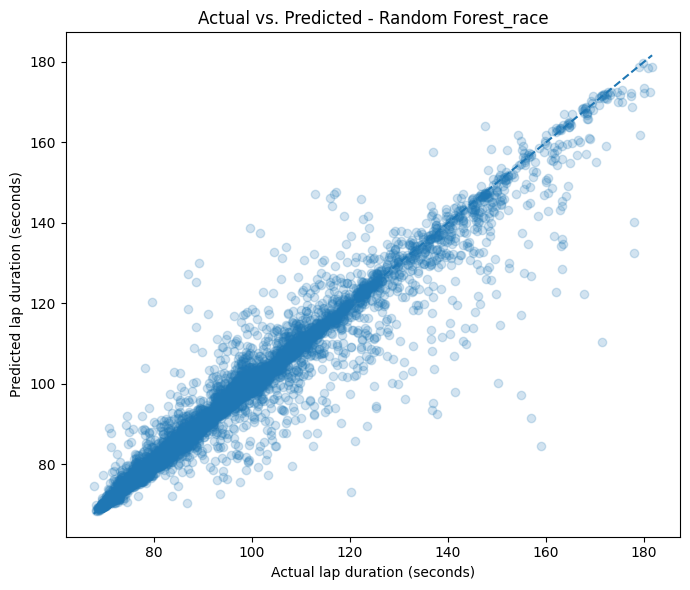

In [94]:
if model_predictions:
    best_model_name = (
        pd.DataFrame(result_rows)
        .query("Model != 'Median Baseline'")
        .sort_values("MAE")
        .iloc[0]["Model"]
    )

    # 
    y_actual = y_race_test if "race" in best_model_name else y_test

    best_predictions = model_predictions[best_model_name]

    plt.figure(figsize=(7, 6))
    plt.scatter(y_actual, best_predictions, alpha=0.2)
    lower = min(y_actual.min(), best_predictions.min())
    upper = max(y_actual.max(), best_predictions.max())
    plt.plot([lower, upper], [lower, upper], linestyle="--")
    plt.xlabel("Actual lap duration (seconds)")
    plt.ylabel("Predicted lap duration (seconds)")
    plt.title(f"Actual vs. Predicted - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Prediction diagnostic: TBD")


### 6.1 Performance by Session Type

Gets the performance by session type for the general models.

In [95]:
if model_predictions and "session_type" in X_test.columns:
    session_results = []

    # get only general models
    general_models = {}
    for model_name, preds in model_predictions.items():
        if "race" not in model_name:
            general_models[model_name] = preds

    for model_name, predictions_general in general_models.items():
        evaluation_frame = pd.DataFrame({
            "session_type": X_test["session_type"].to_numpy(),
            "actual": y_test.to_numpy(),
            "predicted": predictions_general,
        })
        for session_type, group in evaluation_frame.groupby("session_type"):
            row = regression_metrics(group["actual"], group["predicted"])
            row.update({"Model": model_name, "Session Type": session_type, "Rows": len(group)})
            session_results.append(row)

    session_results_df = pd.DataFrame(session_results)
    display(session_results_df.sort_values(["Model", "MAE"]))
else:
    print("Session-specific model results: TBD")


,MAE,RMSE,R2,Model,Session Type,Rows
8,7.877,11.611,0.423,Lasso Regression_general,Race,20256
7,15.778,19.304,0.228,Lasso Regression_general,Qualifying,3974
6,18.462,22.809,0.152,Lasso Regression_general,Practice,14164
2,6.764,11.020,0.480,Linear Regression_general,Race,20256
1,15.614,19.036,0.249,Linear Regression_general,Qualifying,3974
0,18.785,22.442,0.179,Linear Regression_general,Practice,14164
11,1.056,3.248,0.955,Random Forest_general,Race,20256
10,6.959,11.560,0.723,Random Forest_general,Qualifying,3974
9,12.076,17.045,0.527,Random Forest_general,Practice,14164
5,6.764,11.020,0.480,Ridge Regression_general,Race,20256


### 6.2 Random Forest Feature Importance


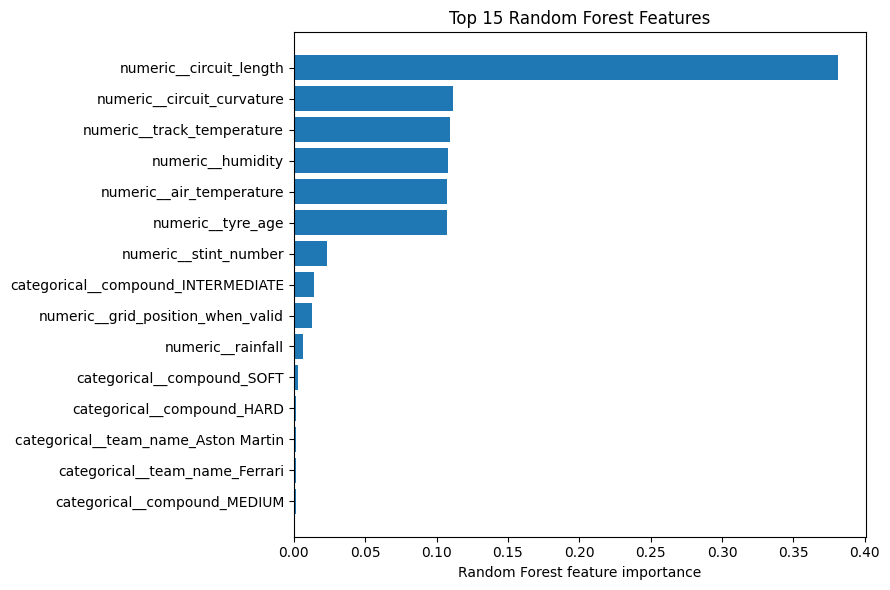

,feature,importance
5,numeric__circuit_length,0.381
4,numeric__circuit_curvature,0.111
1,numeric__track_temperature,0.109
2,numeric__humidity,0.108
0,numeric__air_temperature,0.107
7,numeric__tyre_age,0.107
6,numeric__stint_number,0.024
25,categorical__compound_INTERMEDIATE,0.014
8,numeric__grid_position_when_valid,0.013
3,numeric__rainfall,0.007


In [96]:
if "Random Forest_general" in fitted_models:
    rf_pipeline = fitted_models["Random Forest_general"]
    feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = rf_pipeline.named_steps["model"].feature_importances_

    importance_table = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
        .sort_values("importance")
    )

    plt.figure(figsize=(9, 6))


    
    plt.barh(importance_table["feature"], importance_table["importance"])
    plt.xlabel("Random Forest feature importance")
    plt.title("Top 15 Random Forest Features")
    plt.tight_layout()
    plt.show()

    display(importance_table.sort_values("importance", ascending=False))
else:
    print("Feature importance: TBD")


### 6.3 Final Results Table - Complete After Tuning

| Model | Final settings | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| Median Baseline | Median training target | Generated above | Generated above | Generated above |
| Linear Regression | TBD | TBD | TBD | TBD |
| Ridge Regression | `alpha`: TBD | TBD | TBD | TBD |
| Lasso Regression | `alpha`: TBD | TBD | TBD | TBD |
| Random Forest | TBD | TBD | TBD | TBD |

### Results interpretation - TBD

- **Best-performing model:** TBD
- **Evidence supporting that choice:** TBD
- **Difference from the baseline:** TBD
- **Effect of Ridge regularization:** TBD
- **Effect of Lasso regularization / coefficient shrinkage:** TBD
- **Signs of overfitting:** TBD
- **Session type with the largest error:** TBD
- **Most influential features:** TBD
- **Practical meaning of the error in Formula 1 seconds:** TBD

## 7. Final Conclusions and Limitations

### Final conclusion — TBD

The final conclusion should state:

1. The exact prediction problem.
2. The four main models tested: Linear Regression, Ridge Regression, Lasso Regression, and Random Forest.
3. The best model and its final MAE, RMSE, and R².
4. Whether it meaningfully improved on the median baseline.
5. What the result means in seconds of lap-time error.
6. Whether regularization improved the linear model and whether Lasso removed any coefficients.

### Current limitations

- The available variables do not fully represent traffic, yellow flags, safety cars, pit entry/exit behavior, fuel load, car damage, or driver-specific incidents.
- Lap observations from the same session are related, so the final split and cross-validation strategy must prevent leakage between sessions.
- Circuit curvature is an engineered approximation and should be validated before strong conclusions are drawn from it.
- 2026 is an incomplete season until all scheduled sessions occur.
- A model trained on recent seasons may not generalize perfectly after major regulation or car-performance changes.
- Final conclusions about feature effects should distinguish model association from causation.

## 8. Team Contributions

| Group Member | Main Contribution |
|---|---|
| Sean Staszewski | Dataset collection, documentation, feature engineering, and model implementation |
| Meechai Kerr | Exploratory data analysis, visualization, cleaning, and preprocessing |
| Miguel Gutierrez | Model implementation, evaluation, and comparison |
| Gabriel Lopez-Garcia | Cross-validation, tuning, preprocessing pipeline, and data cleaning |
| Andres Chavez | Results interpretation, presentation preparation, and delivery |

Not too sure how accurate this is, this section should be updated as we go.

## 9. Final Submission Checklist

Before submitting, confirm that the notebook includes:

- [ ] Problem and dataset overview
- [ ] Clearly defined target variable
- [ ] Exploratory data analysis and visualizations
- [ ] Data cleaning and preprocessing
- [ ] At least three machine learning algorithms
- [ ] Model tuning and evaluation
- [ ] Consistent RMSE, MAE, and R² results
- [ ] Model comparison and results interpretation
- [ ] Identification and justification of the best model
- [ ] Final conclusions and limitations
- [ ] Summary of every member's contribution
- [ ] Clear Markdown explanations
- [ ] Readable code
- [ ] Outputs that run successfully

**Final step:** Restart the notebook environment and run every cell from beginning to end before submission.